# Intelligent Automation 2026/27- Assignment 1

To be delivered until 2026-10-09 23:59:59.

**Submission Notes**:
- Create a folder in your group's GitHub repository to solve this assignment. Copy this notebook into that folder.
- You should commit regularly to your repository the answers to the questions in this notebook. If you do not, your grade will be penalized by 1/20 points.
- After running the entire notebook (including graphs and outputs), save the notebook as a .pdf file, by going to File - Print - Destination: Save as PDF.
- Create a .zip file containing both the .ipynb file (the notebook itself) and the .pdf and submit it in Fénix.

# Problem description

The dataset for this assignment contains information on students from two Portuguese secondary schools enrolled in a mathematics course.
Each row corresponds to one student and includes demographic and family background variables (e.g., basic personal and household characteristics), school-related variables (e.g., school context, study habits, past failures), behavioral and lifestyle indicators (e.g., free time, going out, alcohol use), and the grades for the three school periods, on a 0–20 scale.

The goal is to predict the performance of the students in the final period.
First, the problem will be approached as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course.
Then, the problem will be approached as a regression task, predicting the actual final grade (G3).

A detailed description of all variables (family context, behavioral, school performance, etc.) is provided in the file `feature_description.txt`.

# Part 1 - Data exploration **(4.00)**

##### **1.1.** Load the dataset from the CSV file `mathematics_grades.csv`. **(0.25)**

In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("mathematics_grades.csv")

# Display the dataset
print(df)

    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
352     MS   M   20       U     LE3       A     2     2  services  services   
353     MS   M   17       U     LE3       T     3     1  services  services   
354     MS   M   21       R     GT3       T     1     1     other     other   
355     MS   M   18       R     LE3       T     3     2  services     other   
356     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... freetime goout  Dalc  Walc  health absence

##### **1.2.** Identify the feature types of each variable in the dataset. **(1.50)**

In [3]:

print(df.dtypes)

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
failed         bool
dtype: object


##### **1.3** Check if the dataset has missing values. If so, discard any row that has a missing value. **(0.25)**

In [4]:
# Check for missing values
print(df.isnull().sum())

# Remove rows containing missing values
df = df.dropna()

# Check again
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
failed        0
dtype: int64
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc       

##### **1.4.** Make a pairplot of the numerical variables, colored by the `failed` variable. **(0.50)**

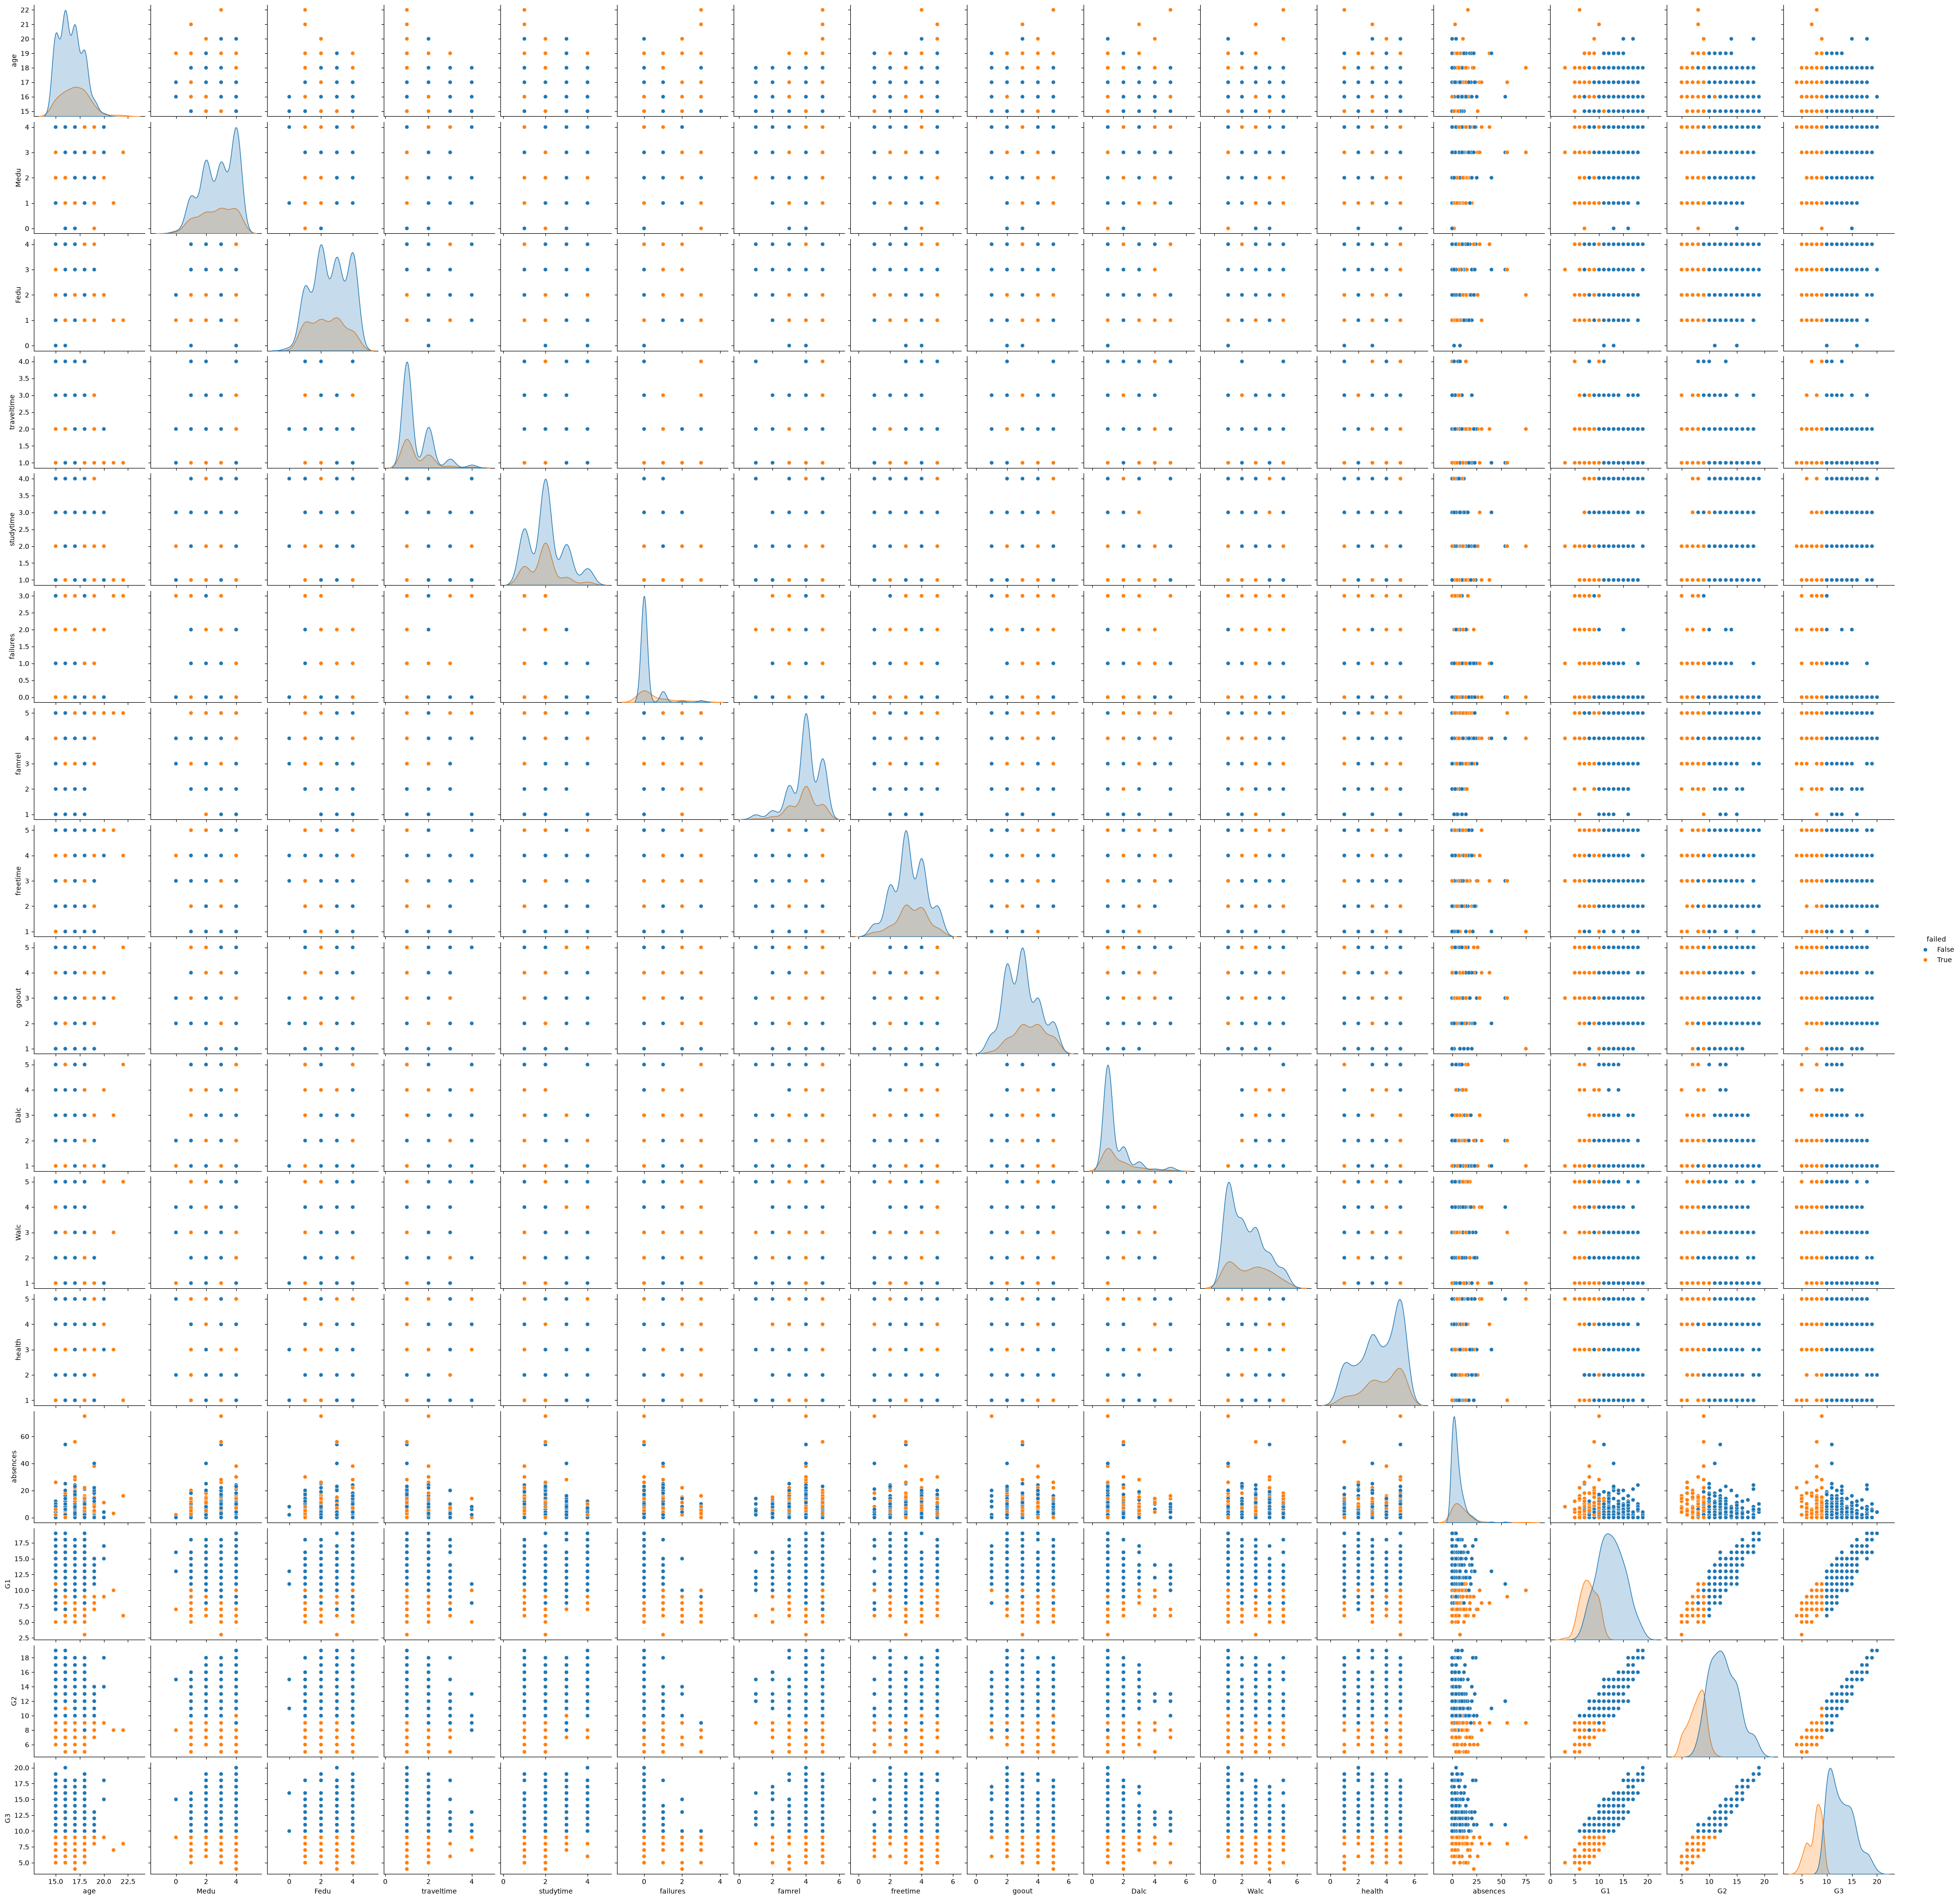

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical variables
numerical_variables = df.select_dtypes(include='number').columns

# Create the pairplot, colored by 'failed'
sns.pairplot(df, vars=numerical_variables, hue='failed')

plt.show()

##### **1.5.** Make bar plots for each categorical variable, showing the counts for each category, colored by the `failed` variable. **(0.50)**

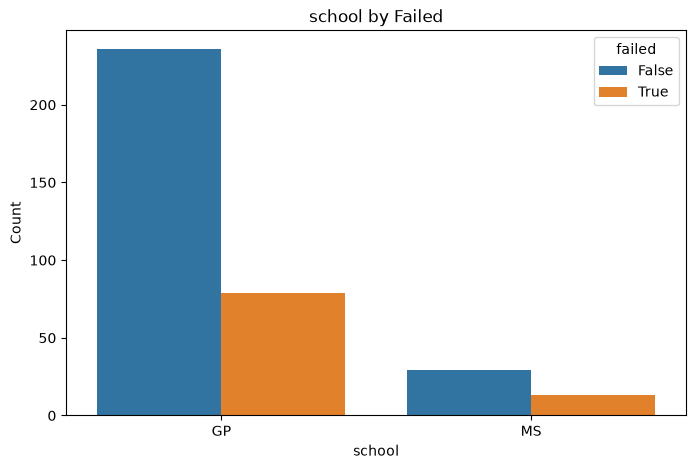

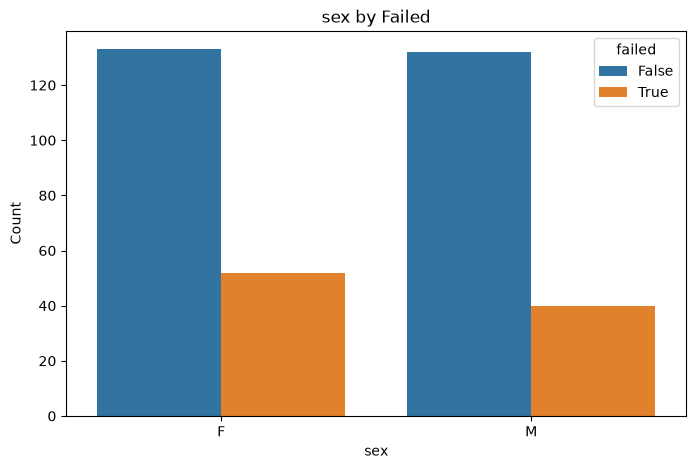

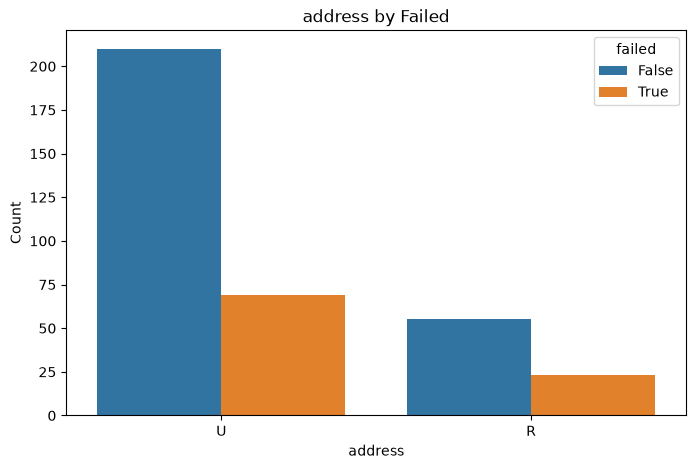

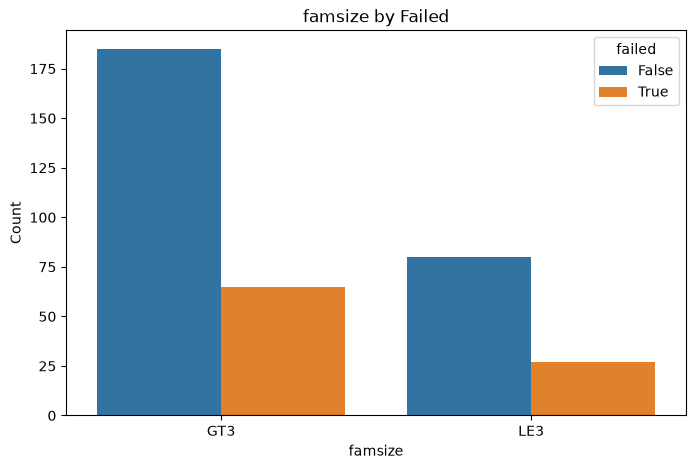

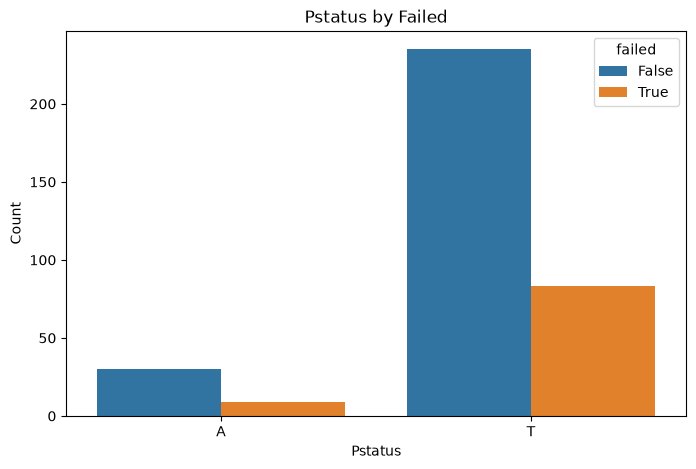

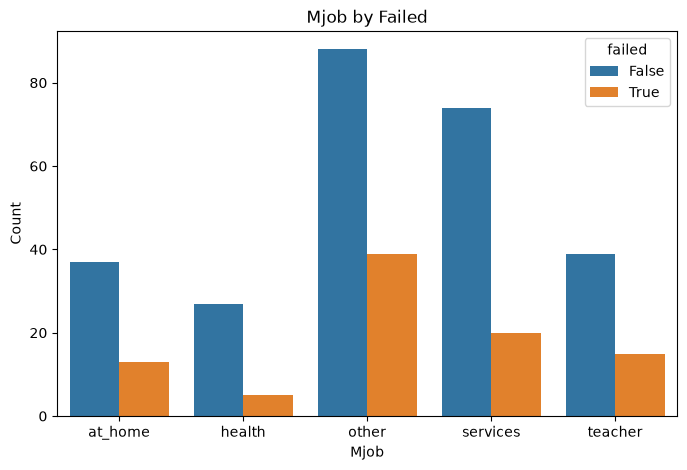

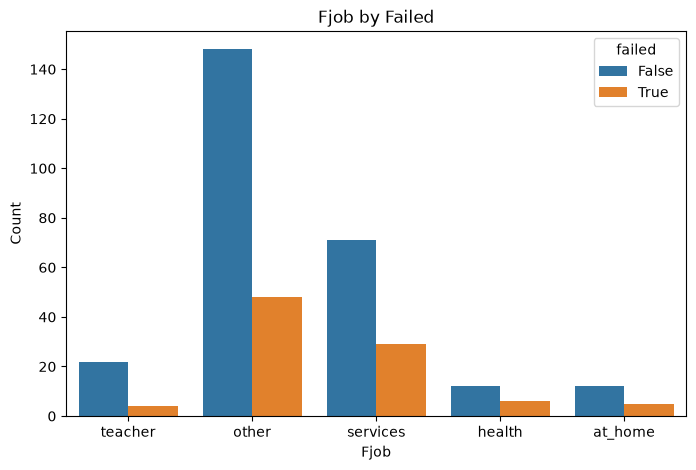

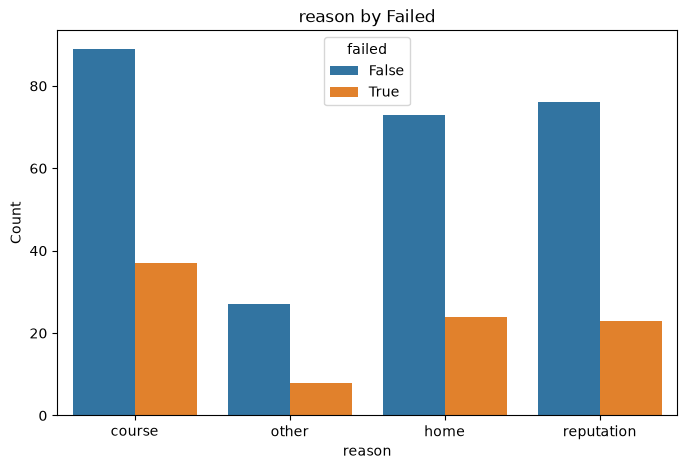

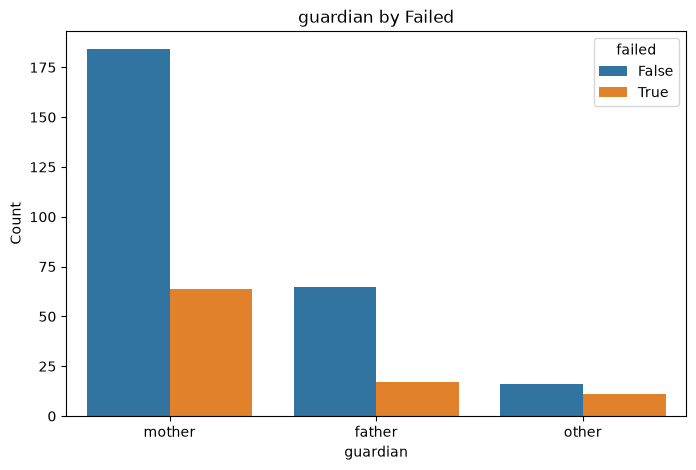

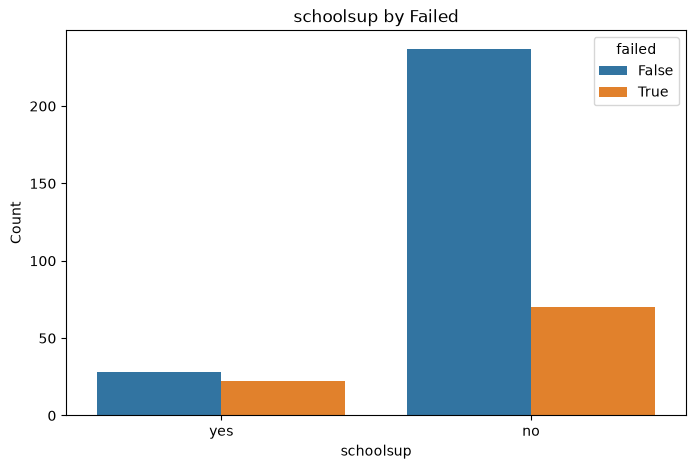

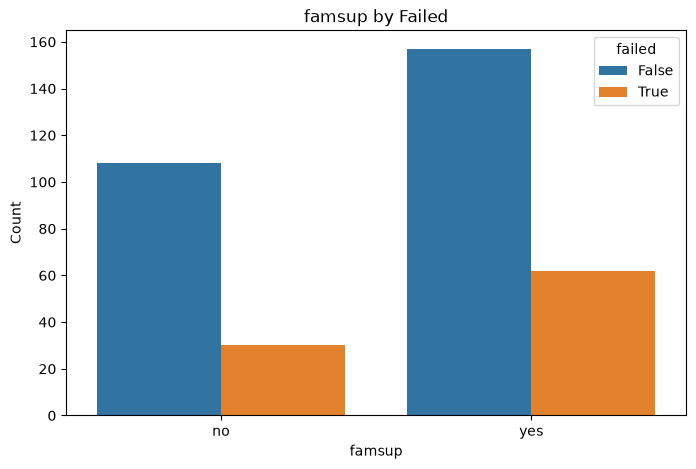

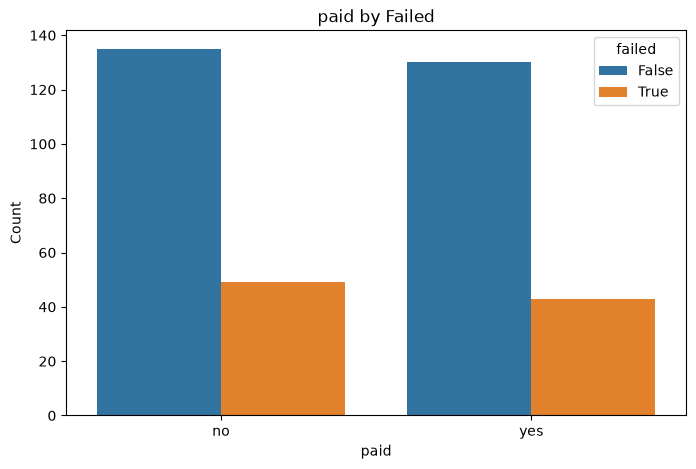

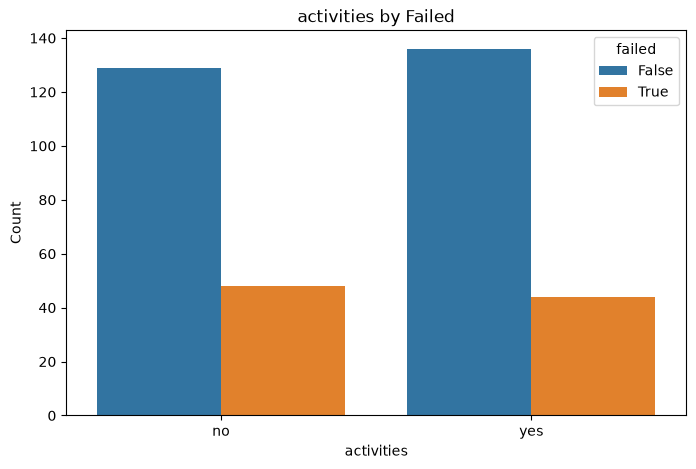

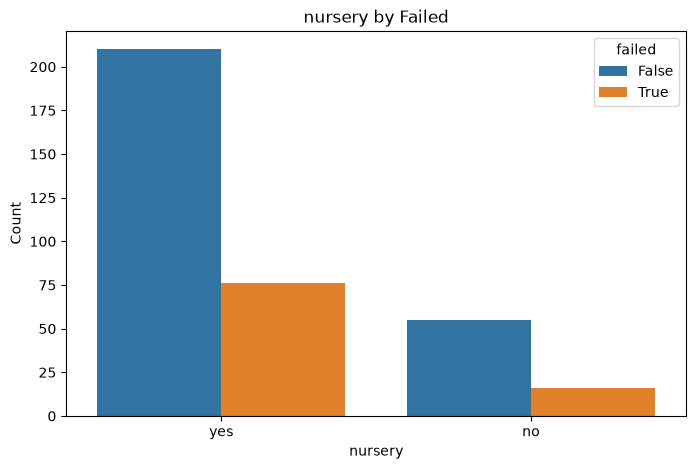

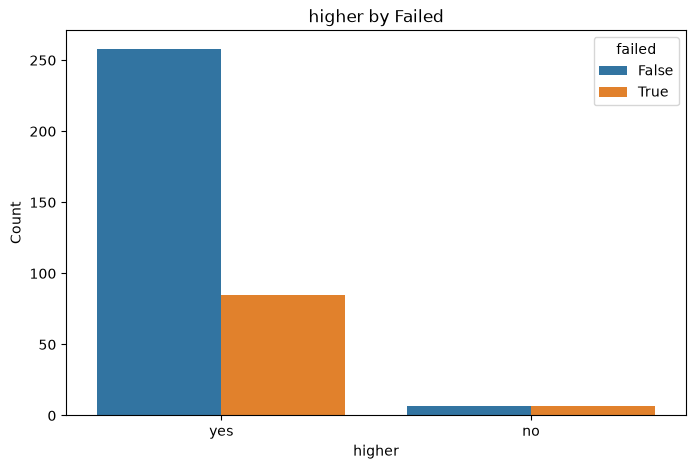

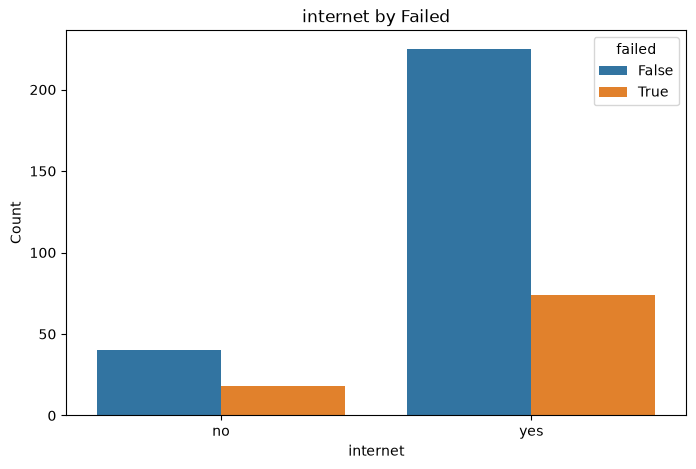

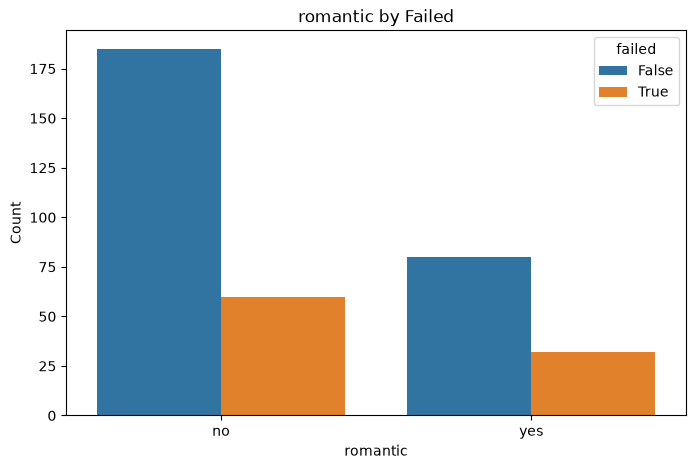

In [6]:

# Find categorical variables
categorical_variables = df.select_dtypes(
    include=['str', 'category']
).columns

# Create a bar plot for each categorical variable
for variable in categorical_variables:
    plt.figure(figsize=(8, 5))
    
    sns.countplot(data=df, x=variable, hue='failed')
    
    plt.title(f'{variable} by Failed')
    plt.xlabel(variable)
    plt.ylabel('Count')
    plt.show()

##### **1.6.** In each school, how many students live in a rural area and do not have internet access at home? **(0.50)**

In [7]:
result = (
    df[(df['address'] == 'R') & (df['internet'] == 'no')]
    .groupby('school')
    .size()
    .reset_index(name='count')
)

print(result)

  school  count
0     GP     17
1     MS      7


##### **1.7.** Split the dataset into a training set (80%) and a test set (20%). **(0.50)**

In [8]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.20, random_state=42)

print("Training set:", train.shape)
print("Test set:", test.shape)

Training set: (285, 34)
Test set: (72, 34)


# Part 2 - Classification **(7.50)**

##### You'll start by approaching the problem as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course. Consider the variable `failed` as the target variable.

##### **2.1.** Which performance metric do you think are most important for this prediction task, and why? Justify your answer in the context of supporting students who may struggle academically. **(2.00)**

The most important performance metric for this prediction task is **recall**, particularly for the class representing students who are likely to fail. Recall measures the proportion of students who actually struggle academically that the model correctly identifies.

In this context, a **false negative** is particularly concerning. A false negative occurs when the model predicts that a student will not fail, when in reality the student is at risk of failing. Such a student may not receive the additional support, tutoring, or intervention they need. Therefore, we want to minimize false negatives and achieve a high recall.

**Precision** is also important because it measures how many of the students identified as at risk of failing actually do fail. High precision helps avoid unnecessarily targeting too many students who do not need additional support.

I would therefore prioritize **recall**, while also considering **precision and the F1-score**. The F1-score provides a balance between precision and recall. Accuracy alone would not be sufficient, because it could give a misleading impression of performance if the classes are imbalanced.

Overall, for a student-support system, it is preferable to identify more students who may be struggling, even if this means that some students who are not actually at risk are also identified. The cost of missing a student who needs help is likely greater than the cost of offering additional support to a student who turns out not to need it.


##### **2.2.** Build a logistic regression model to predict whether a student will pass or fail the course, using as predictor the feature `absences`. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Predictor and target
X = df[['absences']]
y = df['failed']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Create and train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[53  0]
 [18  1]]
Accuracy: 0.75
Precision: 1.0
Recall: 0.05263157894736842
F1-score: 0.1


##### **2.3.** The model you built in question 2.2 likely does not perform very well. Explain why this is the case, considering the distribution of the predictor and the response. How can you improve the model? **(2.00)**

The model likely performs poorly because **absences alone are not enough to predict whether a student will pass or fail**. There may be considerable overlap in absences between students who pass and fail, making it difficult for the model to distinguish between them.

The `failed` variable may also be **imbalanced**, with more students passing than failing. This can result in good accuracy while still missing students who actually fail.

The model could be improved by including more relevant predictors, such as **previous grades, study time, and previous failures**. If the classes are imbalanced, techniques such as **class weighting or oversampling** could also improve the model, particularly its recall.


##### **2.4.** Consider now the variable `studytime` as the predictor and assume it is numerical. Build a logistic regression model to predict whether a student will pass or fail the course. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

Note: Use `sklearn.linear_model.LogisticRegression(class_weight='balanced')` for your logistic regression model.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Predictor and target
X_train = train[['studytime']]
X_test = test[['studytime']]
y_train = train['failed']
y_test = test['failed']

# Create and train logistic regression model
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[11 42]
 [ 4 15]]
Accuracy: 0.3611111111111111
Precision: 0.2631578947368421
Recall: 0.7894736842105263
F1-score: 0.39473684210526316


##### **2.5.** Repeat question 2.4, but now considering `studytime` as a categorical variable. **(0.50)**

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Convert studytime into a categorical variable using one-hot encoding
X_train = pd.get_dummies(train[['studytime']], columns=['studytime'], dtype=int)
X_test = pd.get_dummies(test[['studytime']], columns=['studytime'], dtype=int)

# Make sure train and test have exactly the same columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train['failed']
y_test = test['failed']

# Logistic regression
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[11 42]
 [ 4 15]]
Accuracy: 0.3611111111111111
Precision: 0.2631578947368421
Recall: 0.7894736842105263
F1-score: 0.39473684210526316


##### **2.6.** What is the difference between the two models you built in questions 2.4 and 2.5? Plot the predictions of each model over the range of `studytime` values in the test set. What are the advantages and disadvantages of each approach? **(2.00)**


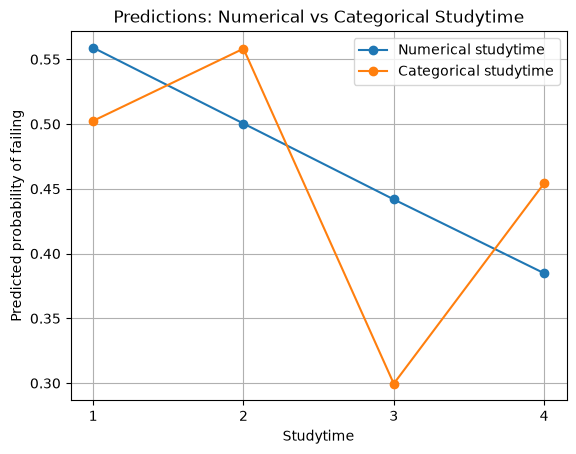

In [14]:
import matplotlib.pyplot as plt

studytime_values = sorted(test['studytime'].unique())

# Numerical model
X_plot_num = pd.DataFrame({
    'studytime': studytime_values
})

pred_num = model_num.predict_proba(X_plot_num)[:, 1]


# Categorical model
X_plot_cat = pd.DataFrame({
    'studytime': studytime_values
})

X_plot_cat = pd.get_dummies(
    X_plot_cat,
    columns=['studytime'],
    dtype=int
)

X_plot_cat = X_plot_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

pred_cat = model_cat.predict_proba(X_plot_cat)[:, 1]


# Plot
plt.plot(
    studytime_values,
    pred_num,
    marker='o',
    label='Numerical studytime'
)

plt.plot(
    studytime_values,
    pred_cat,
    marker='o',
    label='Categorical studytime'
)

plt.xlabel('Studytime')
plt.ylabel('Predicted probability of failing')
plt.title('Predictions: Numerical vs Categorical Studytime')
plt.xticks(studytime_values)
plt.legend()
plt.grid()
plt.show()

The model in question 2.4 treats studytime as a numerical variable, assuming that the effect of increasing studytime is approximately linear. Therefore, the predicted probability changes smoothly across the values of studytime. In question 2.5, studytime is treated as a categorical variable using one-hot encoding, so each studytime category can have a different effect on the probability of failing.

The numerical approach is simpler, requires fewer parameters and is easier to interpret, but it may be too restrictive if the relationship between studytime and failure is not linear. The categorical approach is more flexible and can capture different effects for each category, but it requires more parameters and can overfit, particularly for categories with fewer observations.

# Part 3 - Regression (3.50)

##### In this part of the assignment, you'll approach the problem as a regression task, predicting the actual final grade `G3`. Use the same training and test sets you created in Part 1.

##### **3.1.** Build a linear regression model to predict the final grade `G3`, using as predictor the feature `G2`. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). **(0.50)**

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("mathematics_grades.csv")

# Predictor (X) and target (y)
X = df[["G2"]]
y = df["G3"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display results
print("Intercept:", model.intercept_)
print("Coefficient for G2:", model.coef_[0])
print("MSE:", mse)
print("R-squared:", r2)

Intercept: 0.2749965178250662
Coefficient for G2: 0.9897184203388342
MSE: 0.6853657381781153
R-squared: 0.9288601808718869


##### **3.2.** Print the equation of the model you built in question 3.1. Plot the predictions of the model as a function of the inputs, along with the actual data points from the test set. Interpret the coefficients of the model. **(1.00)**


Linear Regression Model:
G3 = 0.2750 + 0.9897 * G2

Interpretation:
Intercept: 0.2750
When G2 = 0, the predicted G3 is approximately 0.2750.

Slope: 0.9897
For every 1-point increase in G2, G3 increases by approximately 0.99 points on average.


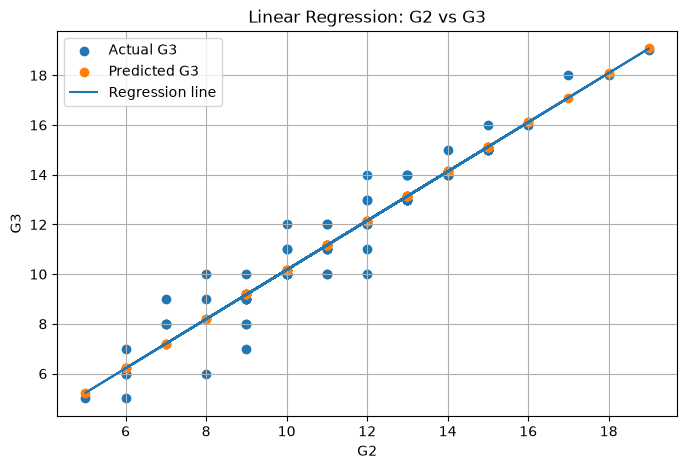

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load the dataset
df = pd.read_csv("mathematics_grades.csv")

# Define predictor and target
X = df[["G2"]]
y = df["G3"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Get coefficients
intercept = model.intercept_
slope = model.coef_[0]

# Print the equation
print("Linear Regression Model:")
print(f"G3 = {intercept:.4f} + {slope:.4f} * G2")

# Interpret the coefficients
print("\nInterpretation:")
print(f"Intercept: {intercept:.4f}")
print("When G2 = 0, the predicted G3 is approximately "
      f"{intercept:.4f}.")

print(f"\nSlope: {slope:.4f}")
print(f"For every 1-point increase in G2, G3 increases by "
      f"approximately {slope:.2f} points on average.")

# Plot actual data and predictions
plt.figure(figsize=(8, 5))

# Actual test data
plt.scatter(
    X_test["G2"],
    y_test,
    label="Actual G3"
)

# Predicted values
plt.scatter(
    X_test["G2"],
    y_pred,
    label="Predicted G3"
)

# Regression line
plt.plot(
    X_test["G2"],
    y_pred,
    label="Regression line"
)

# Labels and title
plt.xlabel("G2")
plt.ylabel("G3")
plt.title("Linear Regression: G2 vs G3")
plt.legend()
plt.grid(True)

plt.show()

The coefficient of G2 is 0.9897, meaning that a one-point increase in G2 is associated with an average increase of approximately 0.99 points in the predicted final grade G3. The intercept is 0.2750, representing the predicted G3 when G2 is zero.

##### **3.3.** Build a linear regression model to predict the final grade `G3`, using as predictors all features except the variables related to the grades (`G1`, `G2`, `G3`, `failed`). Explain the choices you made. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). Plot the predicted vs actual values of `G3` for the test set. **(1.00)**

##### **3.4.** In terms of application, what is the difference between building a model to predict student performance using the grades of the previous periods (as in question 3.1) versus using other features (as in question 3.3)? When would each approach be more appropriate? **(1.00)**

# Part 4 - Cross-validation (4.00)

##### **4.1.** Explain the concept of cross-validation and its importance in evaluating machine learning models. **(1.00)**

##### **4.2.** Describe how K-fold cross-validation works. What values of K should be used? Justify. **(1.00)**

##### **4.3.** Explain how K-Fold cross-validation should be done to choose the classification threshold for the logistic regression model of Part 2. **(2.00)**

# Part 5 - GitHub (1.00)

##### **5.1.** Describe how your group used GitHub to track changes throughout the project and explain why maintaining a clear change history is important in data analysis and machine learning work. **(1.00)**